# Mô hình Multi-channel LSTM-CNN cho Phân tích Cảm xúc Tiếng Việt

Môn học: Deep Learning — Học viên: Nguyễn Đặng Nhật Minh, MSHV 25C15052

Báo cáo này tái hiện kiến trúc mạng nơ-ron kết hợp CNN và LSTM được đề xuất trong bài báo:

> Vo, Quan-Hoang & Nguyen, Huy-Tien & Le, Bac & Nguyen, Minh-Le. (2017). Multi-channel LSTM-CNN model for Vietnamese sentiment analysis. 24-29. 10.1109/KSE.2017.8119429.
> [ResearchGate](https://www.researchgate.net/publication/321259272_Multi-channel_LSTM-CNN_model_for_Vietnamese_sentiment_analysis)
> · [Source Code](https://github.com/ntienhuy/MultiChannel)

Báo cáo đồng thời huấn luyện và đánh giá **base model** cùng một **improvement** trên một bài
toán phân loại văn bản tiếng Việt thực tế, so sánh performance giữa hai mô hình bằng các metrics.

---

## Cấu trúc báo cáo

| Mục | Nội dung |
|-----|----------|
| §1 | Bài toán và bộ dữ liệu |
| §2 | Thiết lập môi trường, tiền xử lý và biểu diễn từ |
| §3 | Kiến trúc mô hình gốc (theo bài báo) |
| §4 | Mô hình cải tiến và thực nghiệm lựa chọn kiến trúc |
| §5 | Huấn luyện |
| §6–§7 | Kết quả, đánh giá và kết luận |

## 1. Bài toán và bộ dữ liệu

**Bài toán:** Phân loại cảm xúc là một dạng text classification. Cho một câu phản hồi tiếng Việt, mô hình dự đoán sắc thái cảm xúc thuộc một
trong ba lớp: *tiêu cực (negative)*, *trung lập (neutral)* hoặc *tích cực (positive)*.

**Bộ dữ liệu UIT-VSFC** (Vietnamese Students' Feedback Corpus, Nguyen và cộng sự, 2018):

- Gồm khoảng 16.175 câu phản hồi của sinh viên, được gán nhãn thủ công với độ đồng thuận giữa các
  người gán nhãn (inter-annotator agreement) đạt trên 91%.
- Ba lớp cảm xúc `0 = negative`, `1 = neutral`, `2 = positive`, tương ứng đúng với không gian đầu ra
  ba lớp của mô hình trong bài báo gốc.
- Đã được chia sẵn thành ba tập: huấn luyện 11.426 câu, kiểm định (dev) 1.583 câu, kiểm thử (test) 3.166 câu.
- Văn bản đã được tách từ sẵn (word-segmented), do đó không cần áp dụng thêm công cụ tách từ tiếng Việt.

**Lý do lựa chọn:** UIT-VSFC là một bộ dữ liệu chuẩn (benchmark) cho xử lý ngôn ngữ tự nhiên tiếng
Việt, có nhãn ba lớp tương thích trực tiếp với kiến trúc của bài báo và có kích thước đủ lớn để
huấn luyện mạng học sâu.

**Vấn đề mất cân bằng lớp:** Lớp `neutral` chỉ chiếm khoảng 4–5% tổng số mẫu. Do đó, bên cạnh độ
chính xác (accuracy), báo cáo sử dụng **macro-F1** (trung bình điểm F1 của các lớp, không thiên vị
lớp chiếm đa số) làm độ đo chính, đồng thời áp dụng trọng số lớp (`class_weight`) trong quá trình
huấn luyện. Đây cũng là độ đo được sử dụng phổ biến để so sánh trên UIT-VSFC.

## 2. Thiết lập môi trường và nạp dữ liệu

In [1]:
import os
import re
import io
import sys
import time
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
import random
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("GPU(s)     :", tf.config.list_physical_devices('GPU') or "None (CPU mode)")

TensorFlow : 2.16.1
Keras      : 3.14.1
GPU(s)     : None (CPU mode)


### 2.0. Tự động tải bộ dữ liệu UIT-VSFC

Tự động tải bộ dữ liệu UIT-VSFC về thư mục `data/UIT-VSFC/` nếu chưa tồn tại, giúp
báo cáo có thể chạy lại độc lập mà không cần đính kèm dữ liệu rời.

**Nguồn dữ liệu:** Bộ dữ liệu được công bố trên [HuggingFace `uitnlp/vietnamese_students_feedback`](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback).
Tuy nhiên, phiên bản trên HuggingFace sử dụng cơ chế *loading script* đã bị thư viện `datasets`
phiên bản 3.0 trở lên ngừng hỗ trợ. Do đó, dữ liệu được tải trực tiếp từ Google Drive, vốn là
nguồn gốc mà loading script của HuggingFace tham chiếu đến (gồm 9 tệp: ba tập train/dev/test, mỗi
tập có ba tệp sents/sentiments/topics).

In [2]:
# --- Tự động tải UIT-VSFC từ Google Drive (nguồn gốc của bản trên HuggingFace) ---
DATA_DIR = os.path.join("data", "UIT-VSFC")

DRIVE_IDS = {
    "train": {"sents": "1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
              "sentiments": "1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
              "topics": "14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C"},
    "dev":   {"sents": "1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
              "sentiments": "1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
              "topics": "1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W"},
    "test":  {"sents": "1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
              "sentiments": "1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
              "topics": "1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB"},
}

def ensure_uitvsfc():
    # đã có đủ file?
    ok = all(os.path.exists(os.path.join(DATA_DIR, sp, f"{k}.txt"))
             for sp in DRIVE_IDS for k in ("sents", "sentiments"))
    if ok:
        print("UIT-VSFC đã có sẵn, bỏ qua bước tải.")
        return
    try:
        import gdown
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    for sp, files in DRIVE_IDS.items():
        os.makedirs(os.path.join(DATA_DIR, sp), exist_ok=True)
        for k, fid in files.items():
            out = os.path.join(DATA_DIR, sp, f"{k}.txt")
            if not os.path.exists(out):
                gdown.download(f"https://drive.google.com/uc?id={fid}", out, quiet=True)
    print("Đã tải xong UIT-VSFC.")

ensure_uitvsfc()

UIT-VSFC đã có sẵn, bỏ qua bước tải.


Ba tập có kích thước 11.426 / 1.583 / 3.166 câu; văn bản đã được tách từ sẵn nên không cần công cụ tách từ tiếng Việt.

In [3]:
# --- Load UIT-VSFC từ file đã tải ---
LABELS = {0: "negative", 1: "neutral", 2: "positive"}

def load_split(split):
    def read(name):
        with open(os.path.join(DATA_DIR, split, name), encoding="utf-8") as f:
            return [ln.rstrip("\n") for ln in f]
    sents = read("sents.txt")
    sentiments = [int(x) for x in read("sentiments.txt")]
    assert len(sents) == len(sentiments)
    return pd.DataFrame({"text": sents, "label": sentiments})

train_df = load_split("train")
dev_df   = load_split("dev")
test_df  = load_split("test")

print(f"train: {len(train_df):>6}  |  dev: {len(dev_df):>5}  |  test: {len(test_df):>5}")
train_df.head()

train:  11426  |  dev:  1583  |  test:  3166


,text,label
0,slide giáo trình đầy đủ .,2
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2
2,đi học đầy đủ full điểm chuyên cần .,0
3,chưa áp dụng công nghệ thông tin và các thiết ...,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2


Lớp neutral chỉ chiếm ~4–5% ở cả ba tập, xác nhận tình trạng mất cân bằng lớp đã nêu ở §1 và là lý do chọn macro-F1 làm độ đo chính.

                 train          dev          test
negative  5325 (46.6%)  705 (44.5%)  1409 (44.5%)
neutral     458 (4.0%)    73 (4.6%)    167 (5.3%)
positive  5643 (49.4%)  805 (50.9%)  1590 (50.2%) 



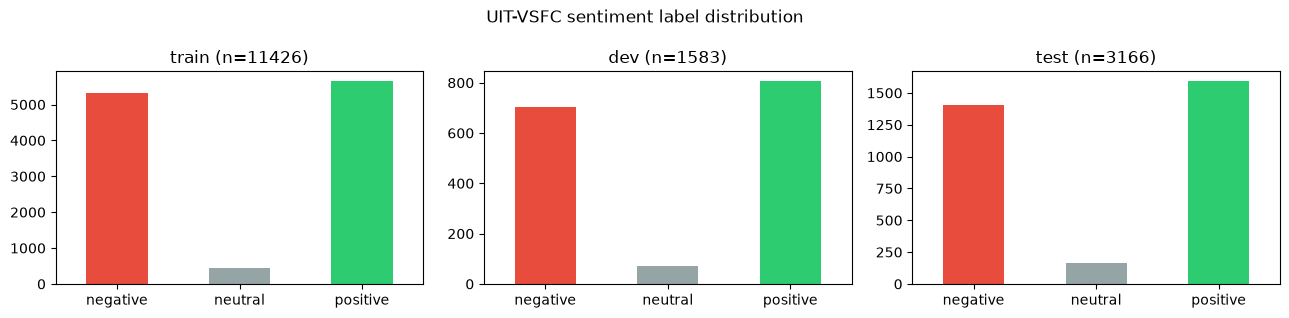

In [4]:
# --- Label distribution (shows the class imbalance) ---
def dist(df):
    c = df["label"].value_counts().sort_index()
    return {LABELS[k]: f"{v} ({100*v/len(df):.1f}%)" for k, v in c.items()}

dist_df = pd.DataFrame({"train": dist(train_df), "dev": dist(dev_df), "test": dist(test_df)})
print(dist_df, "\n")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, (name, df) in zip(ax, [("train", train_df), ("dev", dev_df), ("test", test_df)]):
    df["label"].map(LABELS).value_counts().reindex(["negative","neutral","positive"]).plot(
        kind="bar", ax=a, color=["#e74c3c","#95a5a6","#2ecc71"])
    a.set_title(f"{name} (n={len(df)})"); a.set_xlabel(""); a.tick_params(axis='x', rotation=0)
plt.suptitle("UIT-VSFC sentiment label distribution"); plt.tight_layout(); plt.show()

## 2.1. Tiền xử lý dữ liệu

Quy trình tiền xử lý tuân theo bài báo gốc, gồm ba bước:

1. Xây dựng từ điển (vocabulary) từ tập huấn luyện bằng `Tokenizer` của Keras.
2. Biểu diễn mỗi câu thành chuỗi chỉ số của các từ.
3. Đệm (padding) các chuỗi về cùng độ dài cố định `MAX_LEN`.

Bài báo gốc sử dụng `MAX_LEN = 400` cho đơn vị văn bản là *văn bản (document)*. Trong nghiên cứu
này, đơn vị xử lý là *câu* phản hồi có độ dài ngắn (phân vị 95 chỉ khoảng 33 từ), do đó `MAX_LEN`
được đặt bằng 100, đủ bao phủ trên 99% số mẫu mà vẫn giảm đáng kể chi phí tính toán.

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN   = 100     # độ dài chuỗi sau padding
NUM_CLASSES = 3

# Văn bản UIT-VSFC đã được tách từ sẵn (cách nhau bằng khoảng trắng) -> tách theo space.
# Giữ TOÀN BỘ vocab (không giới hạn num_words) để pretrained embedding phủ tối đa.
tokenizer = Tokenizer(oov_token="<OOV>", filters="")
tokenizer.fit_on_texts(train_df["text"])

def to_seq(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding="post", truncating="post")

X_train, X_dev, X_test = to_seq(train_df["text"]), to_seq(dev_df["text"]), to_seq(test_df["text"])
y_train = train_df["label"].to_numpy()
y_dev   = dev_df["label"].to_numpy()
y_test  = test_df["label"].to_numpy()

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Vocabulary : {len(tokenizer.word_index)} từ")
print(f"X_train shape      : {X_train.shape}")
print(f"Ví dụ chuỗi đã mã hoá: {X_train[0][:15]} ...")

Vocabulary : 2515 từ
X_train shape      : (11426, 100)
Ví dụ chuỗi đã mã hoá: [123  48  54 126  94   2   0   0   0   0   0   0   0   0   0] ...


In [6]:
# class_weight để bù cho việc lớp 'neutral' rất hiếm (~4%)
class_weights = compute_class_weight("balanced", classes=np.array([0,1,2]), y=y_train)
CLASS_WEIGHT = {i: w for i, w in enumerate(class_weights)}
print("class_weight:", {LABELS[k]: round(v, 3) for k, v in CLASS_WEIGHT.items()})

class_weight: {'negative': 0.715, 'neutral': 8.316, 'positive': 0.675}


## 2.2. Biểu diễn từ bằng vector tiền huấn luyện PhoW2V (cho mô hình cải tiến)

Một hạn chế của mô hình gốc là lớp `Embedding` được học từ đầu trên một từ điển nhỏ (khoảng 2.500
từ của UIT-VSFC). Với lượng dữ liệu hạn chế như vậy, các vector từ thu được thường có chất lượng
biểu diễn thấp và khả năng tổng quát hoá kém.

Để khắc phục, mô hình cải tiến khởi tạo lớp embedding bằng **PhoW2V**, một bộ vector từ tiếng Việt
tiền huấn luyện ([Nguyen và cộng sự, EMNLP-2020](https://github.com/datquocnguyen/PhoW2V)) được
huấn luyện trên kho ngữ liệu khoảng 20GB. Báo cáo sử dụng phiên bản theo âm tiết (syllable-level)
với số chiều bằng 100. Tỷ lệ từ trong UIT-VSFC có vector tiền huấn luyện tương ứng (coverage) đạt
khoảng 86%.

*Ghi chú kỹ thuật.* Tệp PhoW2V gốc có dung lượng khoảng 1.1GB (979.000 từ). Để báo cáo gọn nhẹ và
tái lập được, ma trận embedding rút gọn chỉ chứa vector cho từ điển UIT-VSFC (dưới 1MB) đã được
trích xuất sẵn và nhúng trực tiếp dưới dạng base64 (nén zlib) trong cell phía dưới.

In [7]:
import json, base64, zlib

EMBED_DIM = 100   # khớp PhoW2V syllables 100d

# Ma trận PhoW2V gọn (đã trích cho vocab UIT-VSFC) + vocab, nhúng dạng base64(zlib).
# Hai biến chuỗi __EMB_NPY_B64__ / __EMB_VOCAB_B64__ được định nghĩa ở cell ngay dưới.
def load_pretrained_embedding():
    M = np.load(io.BytesIO(zlib.decompress(base64.b64decode(__EMB_NPY_B64__))),
                allow_pickle=False)
    meta = json.loads(zlib.decompress(base64.b64decode(__EMB_VOCAB_B64__)).decode("utf-8"))
    saved_wi = meta["word_index"]
    # Căn lại ma trận theo word_index hiện tại của tokenizer (đảm bảo khớp index).
    idx2vec = {w: M[i] for w, i in saved_wi.items() if i < M.shape[0]}
    M2 = np.random.normal(0, 0.1, (VOCAB_SIZE, EMBED_DIM)).astype("float32")
    hit = 0
    for w, i in tokenizer.word_index.items():
        if w in idx2vec:
            M2[i] = idx2vec[w]; hit += 1
    print(f"PhoW2V matrix: {M2.shape}, coverage ~{100*hit/len(tokenizer.word_index):.1f}%")
    return M2

In [8]:
# (Dữ liệu nhúng, không cần đọc/sửa) Ma trận PhoW2V + vocab, base64(zlib-nén).
import io
__EMB_NPY_B64__ = "..."
__EMB_VOCAB_B64__ = "eNptneuKJFeWpV+lp6CnukDVuB27z6XnEfrf/BoYPNw9w73Cwz3kl8jIahpaNIUQQohECCGEUKaSHFVKlWRJqUJkBEX9CFW9R/aTjNn61jbzgYFMwraZ27FzXWfvffY6519+8XC7m//v1Wa+uPnFf/m7f/nFf/vnf/6f/9RdZe/83S/+sfubur/vdH/z7u/16v7bTXdddNfnq7e3zzbnnVR20vzt7dNH3XXVXR+Wb2+/6YW6E/arzbK7bLrL5du7j2bdddtdn90/WfUfmfS/v/+DfpP1n7xY3v+oVLP+w9f3T/rL/tuz+9f9Zf/p3dvb54de6L+8Wa7e3r0vsf/4bLntL/tP9w/+/dhLTfzuPYl9Bg5vb19e9cWbKPd3v+uvM3J/932fzZT01R/7yz4Dl13G+us+BxvqIZXK/teX/XX/9eu3d1/05Uq1U3qhlPrv//z4b398e/dMcp+Bi67+/tInkvc5WP7tqa4zZ01Cn4FFn3auCnh79820F/oMLKd9Bef999fdN/uS5H0GlvdPVJd5rcw/7T+XN3r79hsl2iovXc307ajq321V4UX/7fX9k/6DRf/pd4/3T/vrXHm6e9zXcVHQRn1bFP3Xr499eYuKd/vLWp3j/mnfDkVDpbzXX7dqnr/9sS9EOdELf+4vM2e1z3eZlKPjo+6dPrulPr5zDyn7r1++vfu8z0pJ67+9e0UvrCjY7VM9JBdv777shUaZ7jNaqu3vXyq5auJW6uuiylwxfV6r5Cdf9i9VOT38uz5HVaFHXQ5v/9J/qSpjMOinVIR6R1Wrp7zWfbVBl+AHvdBqLHXdtm+eeuKMqzfUGf3xuQpVJ5Xxb39Eyi3114zBqd4p1YO67vUFv6voUf2HazfHbd9F6j4X8yM/6jPxn/qh2X//4u3dm/6atvihT7WhDu7/0F+rGVYuckMV3H/bd5WmpIVU5Kb/8qZroP7TDeV/0vfUpokE+nw0/bevlu6S7USdTUVp1Qm7RuwTaPscnL29+7C/zt083/SCUKDvR606wc//riK1lZLtsi9JQ+CvLxAajeC+g7YxAj4HZybUfw8Wl5IzgEc4Mkk81HWufHYtLalgqD7ldyCBQU2doG9fwc1EONihioQ+I7v7P+lanVH9MhMSdv3j2ZUkQ+FTCTSE0spAImFtJjDsq/EZSZSM8+ck0WfiXqiSCQ5/fnx/S4kzRuXtnQSj4V+EuRP1sCl4LDw8O769+1TpCxD369V8ISk3xFJIwWLXiwTSwsW+S2sayBKzQt9BvzS2q1eqa2VCx656HkugZ9w/VRlyBmj0u0zweGmMzXJmCCUihLx/ya8KN/AnkoRS9y91XXlwSejzsBYokylwcqr2zGmahQTB5OZ8qXILJq+6wnSIrdcKzxOWcsZGiH1e1kemjkyIeQY0ZgWA5aIWtYt69z4/VWaOTqWlZZ+pgwo7zzpJyQg+N0smSsGnUDUzcp5UutDTTSvwPBsqtox5+7kaTOjZdZDnyorgk5S+mOlGn50RATPh6GwZs7KR9F7DpGIAMXlXnko0EgSkXY//WI0pGL1kJsqEokILyzUNAHxmAtP9VP1OWHr59vaVciYs7fqSWltQurbKkglKZwy22vn4TgJTmoc1WNpN3Hy5jopx+rVn8qmkhrb+mg/QSHQuQHXJBJwJVvdvb9UwwtW3d1/pus/IuXEwa1AtQJ4mxhCN3nh2V/4bOsv9rQS0m/vX/C66ihQd9xRQoEW9uX+pmTZrmVui1QSw+/unCEVgojWmPjM3x0euy5ZZ7laFaxnLX6vnCGeXodAJav/XL6RmGeR1rS57rq4pbUko21X6+xJQdkI9KzQOOnjgl8w2nSap9kkTJpzbV1LBJsw4X/tZYxx4KkkV8zddo3Z2pfudtDih7Wwc0iljSH99lBAzj1AwWQO9+wRJmLuMmklGXWVdqLuPVNRXPFElge5ya2UlJQYQaJ1SFuipNwW7m/MtbZ+Eu91vwfIk3N11Wh+SFEJPgAncDZVUmNt1hu/9sGGqfqUmSeCdtMqUT9wzhKdJqJt0lWLqlJQL8gGBJNTtkn+FVBqjVKLcE/MbCdLNh9cahvbPLyT12ZhvpWZPGE7o4kLdS/erVEQ+PqEsAt1OUfhUgpXEz1TqwsPI/UegexhbGtjdHS01mCPqTALdrl3VCCWGioZzAnLP0UVSaWDpSsRP+8x0LatrxtH9j/p4Seed8jEwd2fTQ5A7izYvo+u+h9gahWgQ4e06Bo/gNgArCW+HaSQJcTeRNUFuD49qc0Fuj4J+s0I1FjqkylPAS/WIqnFen0kiO1srHkmo22nwCGFEPSbZOnnyjyoX+PaqOT1P8HsZL5cxk6gJhL69AvKJCiP0tRVWu9/0JeW3fabO//pC6TSekWihhikbnE7C32tr88maLdeFlAgqoPHIfnv7gofVoIuoLoXB6+if6LdSSZMguPv2ZzL1Jth6KJepzVzAl4gJrelDAUab26L5WFKoMR9hM5ZKiAEgAJ5vj2frxXyrPiEU7pvkJ34t9WErVS0Jhneh8OaC4g5ADhL6DP1KV31e5hqjuTD4H3RVYMF9J9Mz4FfTS46ea/DNBb49FLrv5cZfXjS+6JeZLZ67D7FVM09MNl2t76KS5oLfQ4d+2Mce3F9JUBPdv6FYGbm5+3BGKhrZxzB7hb+9YqlSZ2gNdx+tZGcbfm8l2ALR9JMLfNeRiLF3pSLhCOhQ4JUkzZBY68ZdjJhcuJvpSkYIwz9PmMM2RXNhbq6rTC3pAgtyzzCiciHuGU1kLbebM3jfyr9GZC7APRx5ST3j/gdlWnDbmY1bCa09N+RIiHvZT7X6Mv6AsTkFuhfLbgqTFKP4I79cgAFKuPDY8SN1VqavXIB7tdz6UYP2FjmQYewvlKhQg5ukzEJP0zcEu/upEhXk2oNSFvY/SCixtJlsckHupldPJKFVRrcrrUfJAZILcjUH6rcVXdZtJ8i93G7n64XEhBb3E24YRrHU07yiv6Jj5YG4z5VrAe4MwyevmJ01s+bAba+FSmrRHl8p+XriXKtxhbaPjEm5sLbr1s/l9qk9K34sIXqr9JZcQHux3KpT4C9Y2eWSC2Y3SyvOOU6Dqd1KLSBBPQhmb8LL1GflxhZ+3iQj8GeSclwhui7stFLqhlkXVSB7Ccjl+A9+FnDmAthrdyIhbA/+uCBygeyeTt1mYSt8KNGqAriYt7k/96EqTBh75oK26Cxdj5ZUoabQqwSvez7QRIpqU4HrWfhCC4Hrenqma4H9aIEVgtgOy5RmgaJr1a0Q0C4HI6sAajX85HibGFSeI9V2tFxJsgn9lQR7Fxm2RRbgpves6h51bdMMTx04K99SkRWe/EnBtqIzIpztPvaFHIWZnVx2ITINGpQKwex1YEQhnJWrDB+jBvT9CwRw7ilCDurKGi2SO4wUuiLRc2XQF0Ja/K+FcLbr/O8hnegHqiM03J06SSG0vXSnKIS4N9IBCuHtLECwwPM6KC+FULezkizFeCaZUOi+RwReunFLSg3uKF23xij9sHALvVA+C1vPsqeKIjmjOF/R5rBECkHujZ23BZq/jI1CiLs5n5JEn4/5YjpfrzYL3bBT9kMJ6r7USmkf1EdTSX1Gfq0rm2fy6hVl2GcqluC2UzB/Ihs4Zc9tyxXouKi/hfB2yuXgDiSRVlNNpCmwvZbnvajs8vlSgjB/0QHEdCdZNivTTBHKrVzuhaD2ahltE1j7QvVT1QE6PGw0Zvn24JtVjdc2he6+kOTM8JrQtp8C5cEoaruqf5Bgd5i87ALbQleVrODwnBR1PQCZvo5WG+6GQmi76x+qhILbA2ZOIbhd2mAoGvcTRozg9irGfBOjGalUD6ZJwNtOFyaRmonaXxOoyGAuGg9kWRwFOu2Qy9bejTsJyU5SKVqF8PaSqhXYzkD6QmDbo6aAQmB7c/+Cd/BuHCPHAtx3pcwUQtvlI60gqLeqP5VC2sPoyysn0TZf8Dz3sgVrD3Ld4r4oJ7ZU1fXKiZ1y8sGUVmnRREu7bn/PD6VBrmY7/TALD5hqpBTKnnsmKYWze8ZpmTEpA+Nlhu9pOyylsaR1jpFTCmrPpW6W6LNdf1bhAdoV1mkpnO2+91KFTaHHfa5EUmb/Kl9Iduv/yG9jcYefFrGGwsM+M6WupFtLWygT7uzbP/FKEwP+PYn2JksNLQf/LU7iUkB7FstyZW5c+URCHi6n91n46fMyDx9NmdNtvUqUV+GK52E9LAReSrb+hKpYoudazyu96BVJFbHqKIEc4UIvC1zcusS7cfeFmo2Vr2HlSXA72663m/3lSiphKdC91OApCy9+vlKhvQyG2VCW6JXormVpQ4ieKdj9H7qyJvdYghUFXWOP9TVKAiyBsvRTCnAfLs72q4MyZdSlGvAp7KzKleHDxSovBbvSRr7y82TL76nl8Iq9sOw1Ib5claE9qyKFvhtNR6Ww93K6WktohpVkiSzN2EtWCnzPaQBB7yxs2NLeXK86l+HQ/dRPCxumFuk7r1kYrFDW41mNEqKOUnul9Llaqo6W+oAaa0J90ZRSNl6pUzsKf2/ccHh1p5eq9Ab/hrpX47XCGIuC34thPODW3aHHlY2n6ecS6MJ/Yg3T65a3aF1lGw7DN6ptQfDaA1wAfKM2tbIru7IU/na9XuOlrVxSAKutwyfHe41Vos9VOq+fjWptJSS+jiqtBMYXgGY1iZVkrZUKh/OJLmM28EtYavvjdC3RrgWWXCe4mF9fSbAlfyuh5Vt/1gruxKrTUZLaR9NGlRlpPuZjWaynWxTULC63EugsT/zIFqNcR5UweC4dXYu6QuE9RkmVubu4VSrB8FlUW5WGKeorP7f6jb+pStbtZINVieGE1VWh8/bq0qXEihAEFVNwPA+3RyU87sa8rvscHVVpOVO2JuJKMHy9mmt1q8LDMBgelYB4F37iKvdYespDqZlASJUP0R4kKxPWPtpKGDzfugS5lyUwDCpUXgz9qsBiCx96VQA1DKZKIPxgN50dVlseS8/DEq+ExF33UvvHitqPfsasoFoKDNbifmF/2Bes30+MbHeSMnskqE5h8M0xRmxVhgYuoZDn9VNlq8QZ9VTXrhiN3aocFhqfOpEGw0/dpmRk47KvBMO49KohIuE7P/NQopYEwPaMVkLfXk39UhK6r0ykqrLd+MyJ1AFiGhiVEe8nkmFoy4tVCX0zjVWB77vHBVENXpWXE6MK5H2sxrKXYWsNohLydkVXG9RMk8fdfrGXXNsy5dUmFrP5Sku3U8Pandsbw3SZhjgZGRlVk2wR0mRC3/WQBdwNU65LVKFnErx0xPeEvV1Do5hVDU0kc7Rq2nC1qQrxNmztGqhaz0xf6RMtJr4u7c69fSNJ1hpmXdUSM3XnMSb8fYDqULW1m53YE6HvzusXlcD3Qt29nkzsWZ9K0ihy0AeOBr9UC3VvWBWtwV1d9ZnISl3a969oErTeYXWuFuDO3UfqScyKXypaJZaKvrmUmDE8tMBQs4y2tHOgzqI+vue3BhZ5zWrB7np6ddgiVrF+upRYS/WWPVNnhPMsdN3G2NJgrglgiIKj+l4tphcrh9Ok8DcqWWHuxf3vlZ9Qfu+e8W6sNMo2qoW5e80mNStphN4kd1tswprQruVWOFDbzYAtWed4loVBdU6nlSmohKz/RmUJdpl26nywZSV5cRw9uc7DWmKeqfMmvHfKt328WnKvrfpGwxY2UygwsAu61A5jkF+gLuyA8e/UUjzQEBqmjprVNLV9EQFPH0rqc/Fw9UAJlLH6+h7BS7iBvqVJBLi1rnCPUQVeSItBV5d2d2vpoTbeeoDWAlwwugZrt7zUuvhS4OoqgP8nxAg9kpD+H5U+9PpaqLu0dlCj9BKVUAt1bzo8UR/B4bDEe1lXXix6LCG8uxqPlU1roKBmLW2IVazrLFaKGQn1sASrPgX82n1QC35t5dZ28d47DAznlOaEuq49J0iwPiX3U43Su9U7jf1BnyC5fl4RSQbCYPDWwtx+zUJCn4vthS5Lr4TwTkUQlvLasOBpqGhiGKnRGkZRp6+p0gW4NMZ0rhvKyvZ8pY8LcvuZQ+EqtWD3fLs9p8XaIhYrqYiAXgqFl9cGR42Xl/g64e5BNkst1J35V80kTKUXloUyh+N8tZWIKfBM13m4ThUdh+NhB2I3wt/1zy8IkCWSYYny30zcQoLVRgh8UBwdC2mMisbhsy91rWG0UnxeRshALJw2mWMG+GHhUfChpDJ8ObxZuS418zXC3dn2Sp/OPKTVbZqMMN7XihScYOMo6g9Fl3CUBm/DblR7G2HuzdGC/B/uvo0gd7U5LHabhXKTKjv/SLgelp39Np74+x94zMS0ULii1F1rBE2EjclP1+RkaYrAeNaYbXLXDJ26iehauVGa3Hn5QEJtBw+JUDH330qQY+j+tZIoCMBhcmiKbHBsKckiecWJ4oC5OztPmiLa6TtJpReBSKkiAkvXdYRykSizo0POmgI9SppSU06MNUqEwNt+WHX4eFhc6velrZInSHY8SLdpBMI3C55E9C21IwQ+u396lIBN/S2CV8bp5Xh6792AOHqH4VF5hY/Zu6mYImmoyjmRe6IR8J7bMdfEshq1XFX2YkuQdUQKjWdCUnCgoeCnqcMFrxFMDK47RR2hwHgBmtoBfhpLAtzrTl+/llQOkSDq/MJcEpF2ef9SNSLA3R8dUd0QuBADUJhbTv5e1wKWo+2ZRpCLzdSg5MYc2hCR64Eg0N3gmGiawd0hqWalQyVpMBUdJdA0EWTynBDdCXonY0+I+2A6W5xtheyNQPdS8NgQOmaNowFwd1METwAKd2ja0QKQqJVpNUDrhSMFG7fkROvc7cRLNXcSMk8TGPKtsHaHAtdOjHJfE1RcRO9eb68XuhPBJa/4QeU25+WI2Fd88YTVRgcSTxzZ91IByn1+rnbb3yxmB8k2RXioWhEQtFnuABHFKQt1vS7WRtSYZ/E2Qhfen/EYd8cPunbkDTNBm3ktGG2ghb0wumJawHcX9mpLzO67a12Hh0GCoy8/upJU0iWxflrh7nyqjCcaSV9PjQfop5JULUSWt3n4pNTSbW6vqoZXm+ON12TRCnI3Ky/UtY5j4AO5uSTEhefWFx5JkN+QSsmNcZSRWN3tQtpAWxj6qWlBLt78tgiVm+mmFd6u7RZuUXJX+8Nig7HQCnIPESDZCnOvtnsENZGVptbeBdzNbdHGArE+A9VBmnQryN3dC+BbL6vZ0dKWZhko4qoV1s4i5KslXtfGQVvi/p7yy9prSmBBG7Fjty94HLkR+LSC3CsIHK0Ad48B3gpu00SXOb1MpnFbRZg5I6XC+S3LvMWzez5QW9qKhfLjbqYxJ9D9zfRa3aCKmAopaq1Adx7o39YoMPqleQ8OcmyFuXuKi4shXP1tPcT3SQpH5nd+kbnRDU687u5IOq0WoOQGadF0A7hb1tb6tQfVGcD7WMGrbUPdMAQaLwtowmoFvA9Xm/n24V4yVvUbPkE8ktFJ2LsOQ7RtYkFYDwW9c5wPrZDXWnyLd2GJ86sV7jZKoHWcyV9IAINR+W0ZRPK/tq1dLhhbrVB3vY2HNhW/C14EXSUCqCcC3zSRS6iTBgvpbHUe9lF3O3eI/QyxCPMFUS6Hiaa37o9VXtYKOzk8Hx9FDhpMqufwKCaonEQaT1B+PW92YkblI8gF7uj5CaENLJl0EvMTGk4nev3vJ5M/CFaKbxCttPKzRmFGcDyExFt5K7IJvt4p1xlR3CQvAO6skTlSbt95kAcmybPlyqjT3bHa+Tskhx1GIwiOd3bHdqIDqF75KSOMjOT2hXzPT4lyoJUEyBHfP8kd+k3Q9iT3Us7XlDrHxWoXXydX7qt+7HDe104r3HhuU0f0HvgHcSbC/16QzyLUvq+o2SI0ru/8XNlb7K4XO2RHvr3xY81dih/uBCOjiyKYnpJRgXRRcm0N40e4O5OhVShihJpBrOvkiGH1Y9xG3yJIBVztjntE8AhywoSAs/NxTDnmjJj0TmzsS43H7cBFojoddxbx790NLxE6p1Wsc79C1JT2NxKv4HvMd9sVvQ892ZygiaD74Wq32C+nuwtuOQj5hX8Ry6gvLXuZ+XNqRfhNBFYn9Pla0cCEoW3nR2NCnXsNiGRqO6tZ3OlkUy6+pIS19fdnTozwxdeUt2bB0CW0k9hh4NnEfuJpiIO9Bb9i0qSBiPRV/CaP+qTHNJ53WUvv5BLPBh8Uol9P/YiQ2+Fr4cJwSxEGfLhcQ/UCTKm5NvOCNFIQMWB6TNo8OCd+rh6mKZYqEbzP1isnFiEL7vNt+JrIRuuVD6hYEwIoTCbIIL/9PZd9pkaSD9S31GEwknoW3drct2Ws+GXZoForTimDAdc7LC3WhAFBRpsYs57Fy0TzBVdNuN6NdShuDliz7yWDDGfH3HS9HiYemHEbxnpm3zLOpSyzc5nrCpUZoc8YBRS433DpRcU35J6wtYFXBysOX3QGKe4mqhOicEAupLhrjO8MVlxQaCDFzZZjsl4lipkhs7Jtlk2WYnkRzhXcuPXgpc8gx3W47H4APe4SFhb8uGuzjmDIwRiDHye3t9Pt81VxCQeA4JAMftxcGnhmgtzADYQj15lBPyF5bfwT3gy+hsmSkORMaCyKiLMk28RWAK6ZA9mWQ6EKk1g8XKHJ9ZO5E1auFnuKgqO5H7yu0tLR91LeMthyfUgsnabEiUl1h/595+YRri8ct5BBmNsvtw+RwKgnTkcjzuZwBltuFt805xhWcAZXrg8ao6KqqCg0Hghz6u0E+++Pu6vdak+PJ7aYoCdulI6t9vOovN9TOajmHdj7sYZhuBAymHRnYBtEuhvzjjOodPI6Uzu1saFFckzTN2Ta0RfwFrLMXpEpbSJ030dIWwaj7lJGgG/02cKuyuDUZQnS6oRVrM/JLuDu7DZwF14iWAX9mOZoCnt6LLJOi4IHrW7OdAKtTrW9XJmVK1Bn/TKDW7cZUa8dhuAzigrDbjfEzGdZGzG2fNwsZvN6W4eGRHJ9zlLJdfhhXzqdPmsTLptQCTz0BOldY5QweM35Yw6Ha/fzY8ccZ1DtroZg7wy6nVlIGXS7gxVn2HaXtkEzyHbzKdc16PQ17F87TJ7Ei17ul9Mig2+3uYewCt1ub6sjg2x3OEIxzuyj+Mxin53jyj+Uc2AKpVgwnpmmzPD70e+Ek+Jjy1QPvQiq3XY3nTFtQLa7st8ng2w3N07CtVt6noZqt7ZaDNVuZkUOqt2D3fRy8XCLMgXfTjGuM2RB1WLq11t0oidwqc3o+hzJK8qPKXdOPM+fKE6eD53OjwvGhRmrKdzWZCwozx9RBkH6as+13NY9IFwht5SWVhKgN1hq0O9mYWsla+hHukLhUDDrKxDwFI33O8qKhr5amzg+cvAokTB94JaahDe1IJWzq9dLRfxmEPEUIUvaJaoUFFy4eOvVBR8SoD/aHg/HM9/wXPOGAgvTx21BYORdTWGDZVDyNl68yuDkXQ29AYLIuV14GaS8nSPesjQEb7yg9YXsTlionly19q54moeUdzkMpCoiST6mrs2EHhEGat4mVukyyHmeh2HmlROug2XFACKCjlRrj7pnSGh3LF1mcPLOwuKEk9eX+0vE2qPtm2D2N0PMJxVT29b6gfwJxrvhmCNlRHaRtmD83t2iIVaMWmqKgfeLbCfUG4uxJv4eeRaSDxgIQ9pDrXHEgLMrDD+PDQ9wc2/pam3w0J6TqMB7GYO0Nc+IiQR6Xstl7ERyhwgvQVEgGcS86+OwyU3rbnT73SU7HvT5+e+/4jqz4btesLHBxArLN+x/IOjebhzXn8HVO17NpwfLJZXrX8Mg/xGhjrIdkdHtGPuw9bR7Cq8Kv/ez3ZE8mq/nAsLXe/jb3zz8bZNzI48QBO/aUIBBkVo5hj74B33WVswsEPeuduREYF4Vvz5b+Zd9zvI0yMR7jFoz9L399oEfO1bpPSR7WF1m4fl8YNhkubfz+YF8ePGRZeMMGt/u/vcI6uTbK7mcs9xgHkYKZD67pzMIff0aaMh9pn6z51qR+tO9Wyx3/NQGybjZGUPr1fmSTArQZ1fr477/zy2b7QTTZ5D81jH7QvObDUS6DKLfesoWG4L2G2IGMkh+/bqz81qQv0O/JssNb3vy3GI5tH3GDVnIpuBnufnV7KORe23SgtebtA6dQff7Jy4dRfQVUqI/rLckWXpd5X2X1g4Yrk3h+tSfL9mUyfuQwPg7sD8GfD8twnzml1VP0/1+cXBzEI0X014eXBQsa2h/u1BI4f0ddqvzc/xUcP/6oe0eNLhfyHdlxyydUcCe5UsFx2ZmAJ5s3gELcB5+NWiAh/s3NDFbXXh4Ctn5ZE0s3DXFqU3R9zYpdSzhfk/b15VVQ9iEGUTADl2ON4jeMeAzpDaixFy8ZuKJwcnhRN9aiLAVXm6sBzPl53a6BPwI3OeeqOAEXg8KK7TAy9jdpWkG2gCZboL+hgcNbmAfV0UuhfDZfHsoEdXf0ckgB662DCrwPTaiae3Wc5pqOtQfqIEEUmcDOdA2JezA85jOYQc61DSDHziHJJQVk6gidreBHtiHHh8QFfbaqUGHwcIrzF1B1SvsTh92PSscNu0OB0vwcPKYFRA6NzxBb2ximiD7i8ATvA7fThHB059bDG8e+gFswa5+CeHICnNYBnSCMThfnHmWgjN4FqMEzuD8fthcZzJEN/hGrHB+Fzcc6/iB0yfAxCsOkAdnR38rWbuiAvCtOwAnK7xBhhUpGIRnsZIBf/B63GQrg0Q4Mzcsg0XYqYt37O6TBwHW7wvpV4v1YY9YDMA54QZZYysnuIQX9y8QgK2v2SgoHxQstyP4TrKO8Jtu9uuoX8KrRy9o4bCTfuL7ne8MIbO0WWEq3St6A/r72p62YBeGqgvB8Mwe6SIo3e5WQvmb6FcC+ePZcXMg6ya82BKAaHi9cnsI6Be/Dp8LVMOzUMegGrb+aWVkIw8lUR+7xexwww2Y9/6KxuSQrJkv8Lqywh6ZobYqiKkvvGeT1iI662TeaYlzbg0t2U213FEcE7ms7J2N1Gts9fwdROagwUMF/fByNbSMYD5mBfiHN/YzwT88cx8R0mdoy7APf368cBrgfDQQBBiilTIYiD3l6BGioo07k4k5DAZiy9e9p5FTdQh2tEaTjP5sYAYFcQxvzQpvGufNn6AhFs5vY5bFM6Sa3YVcJWytMYrtsC0AfYhw7OPZJSohdMSIFtRfbseq0leIsdfGh+RXcP9bLjVPL1zONhYp31hmSdDV12IUbg90Dy+hspmaGYqdavoOYgblkW27JrTe7xFyk71dW1AUtfuTfx0hwI8RTWf9EqkOZcHQBFWxdreBq3g23aOtQlY8w1lmquLKkAhXceMQ7Qy24mxqIQKkxQPO4CouB25EVgZZ5gV7imUEJgyigyReWWwh3fKqYD5L7E2WMu9t6GdyNvqRTOd8WbaIjmL5NH7aZ6kuucbe+QNCzerAAkm+flZmyvDE4EKAs3hDbeTm2L60OBg6nUnDndyBH0h9bh4c16SbD6pxYg0F1qLvkP/cuswH1DAe9sU0LDqYi4dQqaAuAjVVzp1wM0QbFEMes5qvxuZI3jIVJuN2yRcF7VnbOLU+g522uLteLR5ypx6y7Cq3Dh/eHviMVEqiUgh4GRwAsBpvtjjuYDVeDbuQwW2cLYfN5kroPX61tGLoZ/Zo0/+szX+L0HiV+g1iO1YDuaomY0kSd4YNRUi9GqvOZcX9vpvOLhAjZsp1LZyfL5yabNgHXKvWlp4wYTnuD7vjzJvtydG2mM4BWXiOvT39wrvvZWM/y7jDnnG2yqA7Ls6310jjBFTW3Clj4RMgqoe9LPx+7d2BHhwpem0djF3uYD7uwscG8ZGqy6mYxh5KXPywH9cRIQD/8RDaBAzI//i3/4OgrLHJIvzHgxWo0hHhMdoa5+kOqY1It2feg3AcC4lSw0Pn5fZkGPgpFHA/LsYS+XE5JkcZ22qc18FR8yK960hWmpoTI4FtlhZX60dsiih7aHu1QMq8r+AUUThraKwmMQZeWZZOvT0srhTvnsGO7O0lpFCpn/pLUsC2NwgNLiyMwWoS/iWcAXAkz2KjR0iSV9MremI1unJSmXMnH2qhbbnDRL5weuU4/EvuhPvrpXeDxDv/tX/feAtfJDOrmH2gTB7GTVCyyu75cJdBmiQ7RcUdBxewAgtxkhK0iTvygp3s8wl/MhEKAn/SRXaKUEa4bm37bNi/0kzXNzzNh4GaWF6ATPnucQViwKXkB/hHqlHvzycT7gw1WFPl3kfESyvQKnuId5BIlQ+bRDhT4RlgV02ZmCgvUCvPz7iWu4K5vDK/J6yTKmJqXIuaFrS7QbjSIFe6oclnQcPeIvSZOm5W/rFUbBAfgqWHFm9CslxtvPPn2OkKP9dqdae944mFaCknKVWiaeFqu9qj28G3nO33CH22fvPu0REEsC09adKDx8mhotXGuaFtuDE0rDv9sCE0m5pWMWBZ14N/OR8WsWFg7i8eefBrbrATDAbm4fIBQuNQAz+LCMk/I9eT2NP7HeQhXx6e9Tgempo744Clx0EKmjrBEmfa4bigtmp7OfGJBicz1p5gZSqW9QqZNSKQHV7mNW9qSrhmJbUKdpCrp8mD/YsYzfnSj73pxRv6g2aF/WK6Q0OAmkmJJgV3TOrab5lhYWh2oEd6rXlLn/E5s4WGz7Pp3mBjwdMk2jyDpjn3HjgZRM3Dzmsh1TgnJLSrynPCdvBvVBHKjk0LY3PtjZHhbJIAfc+8zSEMOIO7GdEwcDf3i04n23vjZRic6xEkIXLSn5GJYbyNBMOvgTQMh8a/FhOCpSn4nHpaNNyQmXfcdSO7D2w9zLaX3Jepzja44xyRTzLusO3xEJkFvbPC3IPc6VqccKfP4na+Ze9+9urDDwfDcxM7PWQwPHuDGolgHJZ+6wjGIRl26/vri3eQvAvON0jynNnvALnz4WKOwK4ZXBNuZr5KBr3TXbFmJ2EHBzkgBZLndew5bJbn/Y+8HlE47DusqaB2nWgWmK47u5s6zcOZZzMXnqfnKX/aG9ax2XEe9eR+CNmzs+S7Wt1xQypIp8wudrvp5oJ7kKHoRwWMSzzSsD57LYMQBHif8/CWw/2cwXnLYH4uF7+kzTQZdLrlhibz9tUssUP/nN97t2WbeqQ5zgQo7XBA6VnIipiI7bRhgRrrWu5Ugz2ELGudS2nhXNqH4JqqYgf+17Hps+an6YF93LL6xDJoGTSaAK617oQMAecJgvlIXyKNE+eEUlRDUzYlN8ywpk6qdlROeV6fKOB8XxPBdEHJTiYBpoX6ZBLwN0+MBAZ2BM5HNAsM0T74k+avY4WQTBF46cFft95ymmZrTIk5LFiQgir60A4yU0V39nPDFTUEkjcv7kJtyiCNWvGmVZsRMMCXMVJncPDUDtXh2pGq2Cf1aCukmvrTnJDP95fTG+RRB2n5hKMwt1EBLdG0XA+7UCOOLZzRYG093vEHB9hFLYVTGmcVZAOpFPpwBqn0+vKho7VglV6E6QGxNGoMXukuDO5mnA9SqrhTseieIdVBHuN0lIn3o7DkxrVohv/9HyzG2u9L8nlqMXBjbN7CdxThsOY6CD5+m43Erd2bbsou1Bl8U2ucNXfirALKqangwWIxP7OFDvd0uZ36efLmFleII5jAYWhOjIWm5Y5jkdmdPY39rqTqRmuhJUtp2MEIsR3ZYWdTAvVgo+5ZeYeMuhmWhKCj9hEdSLLsOxtz41dPhi15Hs2FDJMCZurm3JMZ3NRrh1TATXVfSNzps3j/xjvO26B5ipR5MmMH+sKBR85pwV5uNwix48iHiPIj5VyPw4EOQIDP1XqLNQtF1Q1BnjRD4D6CpJplw+7GJYloprii92ueyNLwEywp2KqXK+wA2Kr9au7lGRY5nNX54L9pPFlMvd++3Un084jMx6XRjCZDmpDlE38SEAt9Nei7GfTVA9uvZs2wX9b7iEXsGvoO8on7gRsQaj0INWP8cno2+yWiF/jfIHmrFOZpuKx72/9wWddBmMyaYf8AXA/QWc+Hcmqa6KzpZ/FzOeB2/m0VPpin8Tg2yHvFEKsJA6Q31d5xM5gtcFt/fnw2AwscwXmGDg+9dbqhi2AxLKerHaIdIgildks5HBb+rSau9dTtrrmhp5ydLaYb3xILbU8eYy9DgmjgufYuVmpaE0Mb68PQXGcxkCG6Ho5z+hNTwjWjUHPC9JrW04wwvaZfaDK4iJZvI17rA8ShY+G2hu+6DncojFd3M//gZLZvuJPHMQ84ZeC+omAkbozdq3UqcvWuuB5ADXW8HW2EOuPGmEsSzGD8v/bBEtKXFvv99HzBDYVR7rZX9kpBhg0LBjJsh3kIcMI4MMLOI4LMIcLOYo2pHSeEhH4IHXZz7pWC1sfXeFqEDLuB65i1J64jrBQIsX24bhxrMc4H/sEJ1lLu5H3JWAtvx+kgw48IRRaob0drIeF5gCXrEnAjG8c93xwXGTIAG8Ls4uaw2OxXRHJAmt0tpnMPLYizF7HZbdaeLDXU/pLqEgJHm8dWDrgBTaHdDUEWsGiv3QzF6I92Jgviv9F22jghjIVzmLQ722SwaGd8VjND5iQUieoOcTIjYFdBou2D1/9AhjQr+JyGrHUg/xBGB5d2E2G85tIGgTODTXswHTmDTTvrVCvcnvBpz1Be4dP2BvejwzKqV7PB9eAygFR7HesyJtVu9141hVf7D49+hZBMB/DRKX3Wjvv4ZURPuEON8wA+Zwi2q83V0c9rjLpBboBv3HjtaDpkeLLaOqJyHvuwFkicruXae/4zvkarIbmRNB2suvk17xBx4cbXnBDRbFBub2hrgvkjDA6+rVhBFL0exwO+h/ZkZYG+3sTpEV8iJjEuuT5RLP32iS/Vr4+aL8oIHNzMK6GQcNsliikk3JmVvTY2nXHUaHtiNKDrQcXdTGMQcjzZ9BGeNNi4x2EtEkruIVZL4eReYKxDyl3jEISUuwyyDKTcYauzrI3zyuLglsnoQ+qGCXeotQWCsgUHJsHHPShIIE0mJ8seOXdkyWw5W2cyrng43RN48x27779AktutG0ac6qOV0xUn8QwnmDnTo52QVQ13hvaU5zJBzOWGfzEGF7bcMK2Mk3hg51o9L7kzzhAuQnaiuHHHm9WIcZNg614MSJImKQIZKCKbJpzHKSCTkylCYyRNxkmi9AccjPIqUqzR6der/ZIbjYI6MvKsWeKXNzc3v+T0o5MhQalPVhnUjdPE+ylwzdb6UtmTubudYThDHMeDJrA0OZkYGrrAiWOpoQAnNkNDHjU/7LAwEgRexyKkic+N/NrHNSU5+ri2bvkl0lhzNTU3Bo9mWnpJk9F0SIlO4QDSoXk0U3QG1vmuUzcYiQk67/SKHGimmF5aIISaytEkMR/OapqM3qVEVZQn44MueOJhShQK5tfD1YFjYmD0Lo9nCLIadqv5ORmDJBDnMcHm3fiYJ6i81xGWm+Dy7iEbpYlJAgX5qHxQAcKQqZZ8n7qYaEI2HIP5lSDyvhv7DiWIvJtV1EPNiHjD4VzsOCb/aoLKqxhW4ERTRHQ2zQ7D3ntpMriUvvNpXBVLAvSaeuxnLR27Dtv5pd8fDmZ9h/O7RDB+TVdmM5zF5QomSILMezYe9sU6IAd8QeM948OaFH6DiyBB4Z0yGDQd6ETDPfJJx+eGPJebK8rDvueUXXNBpyQcVjPtWJug8T7YTc8vF5vD1LuVJti850RNJXN5fY4SRN62/HuEEX0ZdO1JhdHOmhoupo/6DYecnhQRnygFm3dzPpyOlk0ivg5JGHx4gGCl7RukWJLh+K44z/IHhCq233RXzU4mhmLCHU8Mj/3+iSKSccbaZNiHjZ9ohlgeEkLyUrqfEc1G0tkJ5Fbc8f7bnIwEpffhbsFpR5B651Mf7aZ8HXc7jjbLshMPPomx6Py/+XAasLbwU3wgzrNmgy0bESTovYfVJZ9NJ/E+FJltdNgpJUHwvYQvkszuHU6vgt5b1Bw4pylg16+40Iym9lrNS1B7jzMxmhPc3j0IBLV35yOkIPf2u3vttmtuyFe0OJilluD4Ck+nl8PnNAxWhyVSy/7AfljEtsaPfRye/DIdGp/2+uwkDIl6LEaPNIUsgmD7udMZ/NFUdeHtmd748egzRx5XdXPfCUby+xzMdxLvQz9i1ZlQ1AT5d0m8bYL7qyOp/LQYdqrqBttx1W9esZgfh4EHH3i+fWjJS/Y+lA9C8P7waE3XYFo4+hg4n58ZIeoJTnBnATO7wwnu0ZqjvCAF732MIZRgF5yxU8VWQX9ychAAFTiTYAH/119xPQ5bxRokH6W5jYP6IAEz9cIBbrU+lbLYf/1Tl9DBp0xlMIDFW6Z3+0zNoPmmIAEPvaYewE6hVsk84Dj1ERaw8cO5cSgcR8HBBl6bZJ1gA5879DBlzcCjtiwTmuWcBCM49qxN2Wg0FMhj3pAZuJz9ByP4P/7tE4TWxz1zgFw22gy5u7nmiRu5GBNs4AerXbj1E4Tgg1WpbAxLyhk1Y1RS7uSGvKFFZ+MkUVGR40JDFlngdJVQe5L3DT65ocrzSZQp+NiWOXDYZ096A0sLJ+pbwZ1K1cz5ksE+8I8JdBAvMcEP9smYsIPn9kimZMvB/ODkwziXsV9eSicrDLJIUzIHYbrhdLwUB8Px6ZPlZq19JQjDq6vrCkmjk33tEnRhm8sJuvDaKixk4dlygSqRRo9SVXMjZ2mT72p6OCN0IKVxesi1VpngDKeLHOEkyIFMJo5Sfe3XfajgBy7iQD54TBuORkLN65ojahsZsIbrJTps8ilGT/yq1zw+RaqgtiGMvYua9q7uDzd25idYw72LIHXg+ABFGvJwv4XQI8TRy1VT5xyavL3sdSVu5Ci/EcOcgkY8pTJZYLAhn+AQz/72lMo5iVJNlHecHlJBbY9xqh1gclbqJMhiiGMmJyRyEpjU+hXtuIXCBps4C8FUeQXyJKjElw/oROWYvYJqLAn0vUZoYwmJdyvCxv8Yh7ja10U9VHHwBUCZIhLp7ktKocngweoGwfwgzqiETLyOMNIEmXi92tCbfRbHcJRsFRt9+5BVyMR5mvDz2gb+1zTByRq0fDEJUvGMNdIEqXi3ePe42i2GRidOdTc4OxLs4h64/4I41ByqEezi+dnVYr7i3FpNC52C09MD6WyNj2pFcNjlx/y6GVu0oo01M1wrGiGlITDJJ+8SrDpOY/CM13EyUYJnfGRlO8EzHk5FhWnc8y7IVxtHvSCxE6DTafGXL6aXDxdTq5fwjTvV7Mbvq2Wnl1v5KVMyJY1DOpKPBL1mUHKEUp+c9bw0TgvJ3b91wIi1aJjHF5dc97lj4OSTk/A8buQ+D4QTdqEd7w9bpjRYxzujdz76lGonJ7rcE38n6HK/Q/Qc//jwDgcPywu9nK+R1JYheCf3PyN5u3JOGz41GDi3WBPCNh6zt/wxtBUfFbq88mnHDXr6EamNUGrOi4VxfLB2Bd34EJEjKU8nkMENH8U1/EBrRuceAfnJCgM2Xn6y5qylmgTzeLYcyaApPznd7j1nK3ZvfUbN5qyiLnGMwUGee+eDlI+LDIkpIT+JVK24UUBILZyAAgfpKeMO9P6Wt832U++G/JoS5uOWZtRocRLMQutoejjbav0uQUE+16JNyh2S9ISGKobDwPlUwSFiHBYM9bibdH5vsR6MYeTGAWAWW60JYq/APh4OC0x5eRLZS0OyWRCKXH7iOUKRzmNrCXf7ICJ/jyQnPnku2To6ulPZePcOpCA/cmq21jy2W8pTnazC0ERjWFLy4DoxDvBgQEK+WI49tPIZGB8hjU6HyomOk1VN81RNWHzOVsvusP9fwwhi8vKQIfg0FRAxP5kkKtI+CVTK/YoCMMPfB0kZ9SofjQYcjHFSKW3CxhP3P9IAJ2sNhi3NC/+ZS4L0/oSQjKNoVsFNNqE1BTl5iuBN9V/72ThYnX02hRtOic5PXEoFRW6Gk+OCyJvy0W4o6E4sQ/NC62M0/kAWWu/WSKlb2/ufub6wGOwLZOiONgNaDIzlXmWr+sYzRGqCmM7nCNpmmGPDEqzl/eq3lvD3vkQYWhSggbV88OpfgrV8TaBYgq9ccoQ7QaqL/ep8g1wTwnuBZB6iwgESVOXd9gwzC67y1Xo6G1QJGMvnNtKgLHfzX6er77hhwjnaCqTlS86jL7KTKMKCO2NHq7hx4u9qudOwENfpsFSLj5T2uPZZp10JrhD77MXm2QnO8rljWhOU5f4UB//YkStd1fTl23OTs8OuF05fbkzKzhbNkRHNDbYvYS17XoxTT+8o9snSswhRCcry/Mi1j2AlECTBVz4jtDYNZGWnO44C1DQYy8vh1HM4y3LuUMJ8JI1pnS4VYTE8QRrdcHQrTQr3P5AakwKhlwmy8sBCTLCVz1APi3FBIcucUh1L3e9TUuaFrRM7yZgAFMryzDZdMc4LFfkuT5br6TzsT7HaU1LobNvZxYK2KuMIOOe+NDXrjUVtWHoOcyzBW77eehwyO+xWVhBhLjM9FbHfkDleqTiZHJA5L+oFA6SyH/oD+wDgLK9ZYCi861BItWxHrqV/P2BUsmMc0RYJqnJntw+yujw5ZUdQmqSOYw5e+necovWNnxIuQDxdKkbIz2ra72QZoaDCzVFw14mDozANC+8aFx2vsdt+b0dl4VWEW77Otvr3hFAnOMuqVCfmDf6dlnyp2HiQlq/mDxAG0FfYYIK0zA1ag6ij0fApvLbsxmsJZAfj4SofYqeRVLQnjHMqxbaAdz1PxclagsjbCdryjO0sErTlxXQP/AwrzNr9OsFbvvoZdwu05eNmdbF4hCx35GFx9euzR7/u/3JXq9/+BcfQcLJkgrs8/+uLEIOMiMTuGSsEx7WJhpjgLXel4kS5BHG5P7R8g5jF3sckfLI16LhNYoLD3EeJIhGc8jTeKf9VL3VdgtilpvrHSdMph+1kUrYVuD33/s+Tf/2/dnGbOQ=="
embedding_matrix = load_pretrained_embedding()

PhoW2V matrix: (2516, 100), coverage ~100.0%


## 3. Kiến trúc mô hình gốc (Multi-channel LSTM-CNN)

Ý tưởng cốt lõi của bài báo là kết hợp nhiều kênh đặc trưng (multi-channel) xuất phát từ một lớp
Embedding dùng chung:

- **Kênh CNN** gồm ba nhánh tích chập song song. Các lớp `Conv1D` với kích thước cửa sổ lần lượt
  là 3, 5 và 7 nhằm trích xuất đặc trưng cục bộ (tương ứng các n-gram bậc khác nhau). Mỗi nhánh
  được tổng hợp bằng phép gộp cực đại theo thời gian (max-pooling-over-time) thành một vector đặc trưng.
- **Kênh LSTM** sử dụng một lớp `LSTM` để mô hình hoá các phụ thuộc tuần tự và ngữ cảnh xa trong câu.
- Đầu ra của tất cả các kênh được **ghép nối (concatenate)**, đưa qua lớp `Dense` và cuối cùng là
  lớp `softmax` ba lớp.

```
                Input (MAX_LEN,)
                      |
                Embedding (VOCAB x 100)      [học từ đầu]
        +-------------+-------------+---------------+
     Conv1D k=3     Conv1D k=5    Conv1D k=7       LSTM(128)
     150 filters    150 filters   150 filters         |
     GMaxPool       GMaxPool      GMaxPool            (128)
        +------(150)--+---(150)------+(150)            |
                      +---------- Concatenate ---------+
                                   (150*3 + 128 = 578)
                                        |
                              Dense(200, sigmoid) + Dropout(0.2)
                                        |
                                 Dense(3, softmax)
```

Cấu hình huấn luyện theo bài báo: bộ tối ưu **Adamax**, hàm mất mát **categorical cross-entropy**.

In [ ]:
CNN_FILTERS = 150       # paper: 150 filters / nhánh
KERNELS     = (3, 5, 7) # paper: cửa sổ 3, 5, 7
LSTM_UNITS  = 128       # paper: 128
DENSE_UNITS = 200       # paper: 200
DROPOUT     = 0.2       # paper: 0.2
EPOCHS = 12
BATCH = 32
# Ghi chú: bài báo dùng embedding 200 chiều. Ở đây dùng EMBED_DIM=100 (định nghĩa ở §2.2)
# để thống nhất với PhoW2V 100 chiều, bảo đảm so sánh công bằng giữa mô hình gốc
# (embedding học từ đầu) và mô hình cải tiến (embedding khởi tạo bằng PhoW2V).

# --- Focal loss cho nhãn dạng số nguyên (sparse) ---
def sparse_categorical_focal_loss(gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        idx = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, idx)                       # xác suất của lớp đúng
        return tf.reduce_mean(-tf.pow(1.0 - p_t, gamma) * tf.math.log(p_t))
    return loss

def build_model(name, use_phow2v=False, trainable_emb=True, bidirectional=False,
                use_focal=False, spatial_dropout=0.0):
    # Hàm dựng mô hình đa kênh CNN-LSTM tham số hoá, dùng chung cho mọi cấu hình.
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32", name="tokens")
    if use_phow2v:
        emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix],
                               trainable=trainable_emb, name="embedding")(inp)
    else:
        emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="embedding")(inp)
    if spatial_dropout > 0:
        emb = layers.SpatialDropout1D(spatial_dropout, name="spatial_dropout")(emb)

    # Ba nhánh CNN song song (cửa sổ 3/5/7) + gộp cực đại theo thời gian
    cnn_outputs = []
    for k in KERNELS:
        c = layers.Conv1D(CNN_FILTERS, k, activation="relu", padding="same", name=f"conv_k{k}")(emb)
        c = layers.GlobalMaxPooling1D(name=f"gmaxpool_k{k}")(c)
        cnn_outputs.append(c)

    # Kênh hồi tiếp: LSTM một chiều hoặc hai chiều (BiLSTM)
    rnn = (layers.Bidirectional(layers.LSTM(LSTM_UNITS), name="bilstm") if bidirectional
           else layers.LSTM(LSTM_UNITS, name="lstm"))(emb)

    merged = layers.concatenate(cnn_outputs + [rnn], name="concat")
    x = layers.Dense(DENSE_UNITS, activation="sigmoid", name="dense")(merged)
    x = layers.Dropout(DROPOUT, name="dropout")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    model = keras.Model(inp, out, name=name)
    loss = sparse_categorical_focal_loss(2.0) if use_focal else "sparse_categorical_crossentropy"
    model.compile(optimizer="adamax", loss=loss, metrics=["accuracy"])
    return model

SEEDS = [42, 7, 123]   # ba seed ngẫu nhiên để đánh giá độ ổn định

def set_seed(s):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

def train_eval_once(build_kw, name, seed, epochs, use_callbacks):
    set_seed(seed)
    model = build_model(f"model_seed{seed}", **build_kw)   # tên model ASCII (Keras yêu cầu)
    cbs = []
    if use_callbacks:
        cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)]
    t0 = time.time()
    hist = model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=epochs,
                     batch_size=BATCH, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=0)
    dt = time.time() - t0
    pred = model.predict(X_test, batch_size=256, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_test, pred)
    f_mac = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)[2]
    f_w = precision_recall_fscore_support(y_test, pred, average="weighted", zero_division=0)[2]
    f_neu = precision_recall_fscore_support(y_test, pred, average=None, zero_division=0)[2][1]
    # Giữ lại pred và history (dùng cho báo cáo chi tiết ở §5, tránh phải train lại)
    return dict(acc=acc, macroF1=f_mac, weightedF1=f_w, neutralF1=f_neu,
                params=model.count_params(), time=dt, pred=pred, hist=hist)

def run_3seeds(build_kw, name, epochs, use_callbacks):
    # Huấn luyện cùng cấu hình trên 3 seed, trả về trung bình và độ lệch chuẩn.
    # Đồng thời lưu dự đoán & lịch sử của seed đầu tiên (42) để §5 tái sử dụng.
    runs = []
    for s in SEEDS:
        r = train_eval_once(build_kw, name, s, epochs, use_callbacks)
        runs.append(r)
        print(f"    seed {s:>3}: acc={r['acc']*100:.2f}%  macroF1={r['macroF1']*100:.2f}%  ({r['time']:.0f}s)")
    agg = {"Mô hình": name, "Params": runs[0]["params"],
           "_pred": runs[0]["pred"], "_hist": runs[0]["hist"]}
    for k, label in [("acc", "Accuracy"), ("macroF1", "Macro-F1"),
                     ("neutralF1", "Neutral-F1"), ("weightedF1", "Weighted-F1")]:
        vals = np.array([r[k] for r in runs])
        agg[label] = vals.mean()
        agg[label + "_std"] = vals.std()
    agg["Train time (s)"] = round(sum(r["time"] for r in runs), 1)
    return agg

Hai điểm điều chỉnh so với bài báo gốc, đều có chủ đích và được ghi rõ: 
- (i) số chiều embedding dùng 100 thay vì 200 để thống nhất với PhoW2V, bảo đảm so sánh công bằng giữa mô hình gốc và cải tiến
- (ii) các siêu tham số còn lại (số filter, kích thước cửa sổ, đơn vị LSTM, Dense, dropout, optimizer) giữ đúng theo [1].

In [10]:
# Mô hình gốc theo đúng bài báo: embedding học từ đầu, LSTM một chiều, cross-entropy, Adamax.
build_model("Base_demo", use_phow2v=False, use_focal=False).summary()

Model: "Base_demo"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    251,600 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 100, 150)  │     45,150 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k5 (Conv1D)    │ (None, 100, 150)  │     75,150 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k7 (Conv1D)    │ (None, 100, 150)  │    105,150 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmaxpool_k3         │ (None, 150)       │          0 │ conv_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmaxpool_k5         │ (None, 150)       │          0 │ conv_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmaxpool_k7         │ (None, 150)       │          0 │ conv_k7[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    117,248 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 578)       │          0 │ gmaxpool_k3[0][0… │
│ (Concatenate)       │                   │            │ gmaxpool_k5[0][0… │
│                     │                   │            │ gmaxpool_k7[0][0… │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200)       │    115,800 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 200)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        603 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 710,701 (2.71 MB)

 Trainable params: 710,701 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
print("="*64, "\nHUẤN LUYỆN MÔ HÌNH GỐC (Multi-channel LSTM-CNN) - 3 seed\n", "="*64)
BASE_KW = dict(use_phow2v=False, trainable_emb=True, bidirectional=False, use_focal=False, spatial_dropout=0.0)
res_base = run_3seeds(BASE_KW, "Mô hình gốc (LSTM-CNN)", epochs=EPOCHS, use_callbacks=False)
print(f"\n>>> Trung bình: acc={res_base['Accuracy']*100:.2f}% "
      f"macro-F1={res_base['Macro-F1']*100:.2f}% (± {res_base['Macro-F1_std']*100:.2f})")

HUẤN LUYỆN MÔ HÌNH GỐC (Multi-channel LSTM-CNN) - 3 seed


    seed  42: acc=89.32%  macroF1=76.08%  (290s)


    seed   7: acc=88.60%  macroF1=75.43%  (275s)


    seed 123: acc=89.01%  macroF1=75.71%  (291s)

>>> Trung bình: acc=88.98% macro-F1=75.74% (± 0.26)


## 4. Thử nghiệm các phương án cải tiến

Để xác định hướng cải tiến hiệu quả, phần này huấn luyện và đánh giá một số phương án cải tiến trực
tiếp trong notebook, trên cùng điều kiện với mô hình gốc (cùng tập dữ liệu, cùng `class_weight`,
cùng số chiều embedding). Mỗi phương án được huấn luyện trên **ba seed ngẫu nhiên** (42, 7,
123) và báo cáo theo giá trị trung bình kèm độ lệch chuẩn, nhằm bảo đảm kết luận không phụ thuộc
vào một lần khởi tạo may rủi. Các phương án tập trung vào hai yếu tố được cho là then chốt:

1. **Chất lượng biểu diễn từ:** thay embedding học từ đầu bằng vector tiền huấn luyện PhoW2V, xét cả
   trường hợp cố định (frozen) và có tinh chỉnh (fine-tune).
2. **Hàm mất mát:** thay cross-entropy bằng Focal loss để tăng trọng số học cho lớp thiểu số `neutral`.

Ngoài ra, kiến trúc Bidirectional LSTM (BiLSTM) cũng được đưa vào để kiểm chứng giả thuyết rằng việc
tăng độ phức tạp của mô hình chưa chắc cải thiện hiệu năng trên dữ liệu câu ngắn.

Các phương án được khảo sát:

| Ký hiệu | Cấu hình |
|---------|----------|
| C1 | PhoW2V (cố định) + LSTM + cross-entropy |
| C2 | PhoW2V (tinh chỉnh) + LSTM + cross-entropy |
| C3 | PhoW2V (tinh chỉnh) + BiLSTM + Focal loss |
| C4 | PhoW2V (tinh chỉnh) + LSTM + Focal loss |

In [12]:
# Định nghĩa các phương án cải tiến (mỗi phương án huấn luyện một lần, cùng điều kiện với mô hình gốc)
CONFIGS = [
    dict(key="C1", name="PhoW2V cố định + LSTM + CE",
         kw=dict(use_phow2v=True, trainable_emb=False, bidirectional=False, use_focal=False, spatial_dropout=0.2)),
    dict(key="C2", name="PhoW2V tinh chỉnh + LSTM + CE",
         kw=dict(use_phow2v=True, trainable_emb=True, bidirectional=False, use_focal=False, spatial_dropout=0.2)),
    dict(key="C3", name="PhoW2V tinh chỉnh + BiLSTM + Focal",
         kw=dict(use_phow2v=True, trainable_emb=True, bidirectional=True, use_focal=True, spatial_dropout=0.2)),
    dict(key="C4", name="PhoW2V tinh chỉnh + LSTM + Focal",
         kw=dict(use_phow2v=True, trainable_emb=True, bidirectional=False, use_focal=True, spatial_dropout=0.2)),
]

exp_results = []
for cfg in CONFIGS:
    print("="*64, f"\nHUẤN LUYỆN PHƯƠNG ÁN {cfg['key']}: {cfg['name']} (3 seed)\n", "="*64)
    r = run_3seeds(cfg["kw"], f"{cfg['key']}: {cfg['name']}", epochs=15, use_callbacks=True)
    exp_results.append(r)
    print(f"\n>>> {cfg['key']} trung bình: acc={r['Accuracy']*100:.2f}% "
          f"macro-F1={r['Macro-F1']*100:.2f}% (± {r['Macro-F1_std']*100:.2f})")

HUẤN LUYỆN PHƯƠNG ÁN C1: PhoW2V cố định + LSTM + CE (3 seed)


    seed  42: acc=80.76%  macroF1=68.97%  (298s)


    seed   7: acc=84.90%  macroF1=72.18%  (285s)


    seed 123: acc=83.23%  macroF1=71.17%  (262s)

>>> C1 trung bình: acc=82.96% macro-F1=70.78% (± 1.34)
HUẤN LUYỆN PHƯƠNG ÁN C2: PhoW2V tinh chỉnh + LSTM + CE (3 seed)


    seed  42: acc=88.88%  macroF1=76.08%  (337s)


...

    seed   7: acc=90.49%  macroF1=77.15%  (567s)


    seed 123: acc=90.56%  macroF1=77.09%  (514s)

>>> C3 trung bình: acc=90.50% macro-F1=76.97% (± 0.22)
HUẤN LUYỆN PHƯƠNG ÁN C4: PhoW2V tinh chỉnh + LSTM + Focal (3 seed)


    seed  42: acc=90.08%  macroF1=76.10%  (323s)


    seed   7: acc=90.81%  macroF1=77.66%  (364s)


    seed 123: acc=90.46%  macroF1=77.11%  (373s)

>>> C4 trung bình: acc=90.45% macro-F1=76.96% (± 0.65)


### 4.1. So sánh các phương án và lựa chọn mô hình cải tiến

Bảng dưới đây tổng hợp kết quả của mô hình gốc cùng bốn phương án cải tiến, dưới dạng giá trị trung
bình kèm độ lệch chuẩn trên ba seed ngẫu nhiên. Việc đánh giá trên nhiều seed giúp kết
luận không phụ thuộc vào một lần khởi tạo may rủi, đặc biệt quan trọng khi chênh lệch giữa các
phương án nhỏ. Phương án cải tiến được lựa chọn là phương án đạt macro-F1 trung bình cao nhất.

In [13]:
def fmt_pm(mean, std):   # định dạng "mean ± std" theo phần trăm
    return f"{mean*100:.2f} ± {std*100:.2f}"

all_results = [res_base] + exp_results
rows = []
for r in all_results:
    rows.append({
        "Mô hình": r["Mô hình"],
        "Accuracy": fmt_pm(r["Accuracy"], r["Accuracy_std"]),
        "Macro-F1": fmt_pm(r["Macro-F1"], r["Macro-F1_std"]),
        "Neutral-F1": fmt_pm(r["Neutral-F1"], r["Neutral-F1_std"]),
        "Weighted-F1": fmt_pm(r["Weighted-F1"], r["Weighted-F1_std"]),
        "Params": f"{r['Params']:,}",
    })
show = pd.DataFrame(rows)
print("BẢNG SO SÁNH (trung bình ± độ lệch chuẩn trên 3 seed, tập kiểm thử UIT-VSFC, n=3166)\n")
print(show.to_string(index=False))

# Chọn phương án cải tiến tốt nhất theo macro-F1 trung bình (không tính mô hình gốc)
best = max(exp_results, key=lambda r: r["Macro-F1"])
print(f"\n>>> Phương án cải tiến tốt nhất theo macro-F1 trung bình: {best['Mô hình']}")
show

BẢNG SO SÁNH (trung bình ± độ lệch chuẩn trên 3 seed, tập kiểm thử UIT-VSFC, n=3166)

                               Mô hình     Accuracy     Macro-F1   Neutral-F1  Weighted-F1  Params
                Mô hình gốc (LSTM-CNN) 88.98 ± 0.30 75.74 ± 0.26 44.02 ± 0.58 89.12 ± 0.14 710,701
        C1: PhoW2V cố định + LSTM + CE 82.96 ± 1.70 70.78 ± 1.34 37.98 ± 1.96 84.65 ± 1.11 710,701
     C2: PhoW2V tinh chỉnh + LSTM + CE 87.77 ± 1.30 75.33 ± 0.94 43.82 ± 1.35 88.62 ± 0.76 710,701
C3: PhoW2V tinh chỉnh + BiLSTM + Focal 90.50 ± 0.04 76.97 ± 0.22 45.72 ± 0.66 90.14 ± 0.08 853,549
  C4: PhoW2V tinh chỉnh + LSTM + Focal 90.45 ± 0.30 76.96 ± 0.65 45.73 ± 1.49 90.12 ± 0.29 710,701

>>> Phương án cải tiến tốt nhất theo macro-F1 trung bình: C3: PhoW2V tinh chỉnh + BiLSTM + Focal


,Mô hình,Accuracy,Macro-F1,Neutral-F1,Weighted-F1,Params
0,Mô hình gốc (LSTM-CNN),88.98 ± 0.30,75.74 ± 0.26,44.02 ± 0.58,89.12 ± 0.14,"710,701"
1,C1: PhoW2V cố định + LSTM + CE,82.96 ± 1.70,70.78 ± 1.34,37.98 ± 1.96,84.65 ± 1.11,"710,701"
2,C2: PhoW2V tinh chỉnh + LSTM + CE,87.77 ± 1.30,75.33 ± 0.94,43.82 ± 1.35,88.62 ± 0.76,"710,701"
3,C3: PhoW2V tinh chỉnh + BiLSTM + Focal,90.50 ± 0.04,76.97 ± 0.22,45.72 ± 0.66,90.14 ± 0.08,"853,549"
4,C4: PhoW2V tinh chỉnh + LSTM + Focal,90.45 ± 0.30,76.96 ± 0.65,45.73 ± 1.49,90.12 ± 0.29,"710,701"


## 5. So sánh chi tiết: mô hình gốc và mô hình cải tiến tốt nhất

Phần này phân tích sâu hơn hai mô hình: mô hình gốc và phương án cải tiến đạt macro-F1 trung bình
cao nhất ở §4.1. Báo cáo theo lớp, đường cong huấn luyện và ma trận nhầm lẫn được lấy từ lần chạy
ứng với seed = 42 của mỗi mô hình trong quá trình thực nghiệm ở trên, do đó
không cần huấn luyện lại.

In [14]:
res_improved = best   # phương án cải tiến được chọn ở §4.1

delta_acc = (res_improved["Accuracy"] - res_base["Accuracy"]) * 100
delta_f1  = (res_improved["Macro-F1"] - res_base["Macro-F1"]) * 100
delta_w   = (res_improved["Weighted-F1"] - res_base["Weighted-F1"]) * 100
print("So sánh hiệu năng trung bình (3 seed):")
print(f"  Mô hình gốc      : acc={res_base['Accuracy']*100:.2f}%  macro-F1={res_base['Macro-F1']*100:.2f}%")
print(f"  Mô hình cải tiến : acc={res_improved['Accuracy']*100:.2f}%  macro-F1={res_improved['Macro-F1']*100:.2f}%")
print(f"\nMức chênh lệch trung bình (cải tiến - gốc):")
print(f"  Accuracy    : {delta_acc:+.2f} điểm phần trăm")
print(f"  Macro-F1    : {delta_f1:+.2f} điểm phần trăm")
print(f"  Weighted-F1 : {delta_w:+.2f} điểm phần trăm")

So sánh hiệu năng trung bình (3 seed):
  Mô hình gốc      : acc=88.98%  macro-F1=75.74%
  Mô hình cải tiến : acc=90.50%  macro-F1=76.97%

Mức chênh lệch trung bình (cải tiến - gốc):
  Accuracy    : +1.53 điểm phần trăm
  Macro-F1    : +1.23 điểm phần trăm
  Weighted-F1 : +1.02 điểm phần trăm


### 5.1. Báo cáo chi tiết theo từng lớp

In [15]:
# Dùng lại dự đoán của seed=42 đã lưu ở §4 (không huấn luyện lại)
for r in (res_base, res_improved):
    print("="*70)
    print(r["Mô hình"])
    print("="*70)
    print(classification_report(y_test, r["_pred"],
                                target_names=["negative", "neutral", "positive"],
                                digits=4, zero_division=0))

Mô hình gốc (LSTM-CNN)
              precision    recall  f1-score   support

    negative     0.9012    0.9255    0.9132      1409
     neutral     0.4591    0.4371    0.4479       167
    positive     0.9301    0.9126    0.9213      1590

    accuracy                         0.8932      3166
   macro avg     0.7635    0.7584    0.7608      3166
weighted avg     0.8924    0.8932    0.8927      3166

C3: PhoW2V tinh chỉnh + BiLSTM + Focal
              precision    recall  f1-score   support

    negative     0.9027    0.9411    0.9215      1409
     neutral     0.5526    0.3772    0.4484       167
    positive     0.9318    0.9277    0.9297      1590

    accuracy                         0.9046      3166
   macro avg     0.7957    0.7487    0.7665      3166
weighted avg     0.8988    0.9046    0.9007      3166



### 5.2. Đường cong huấn luyện và ma trận nhầm lẫn

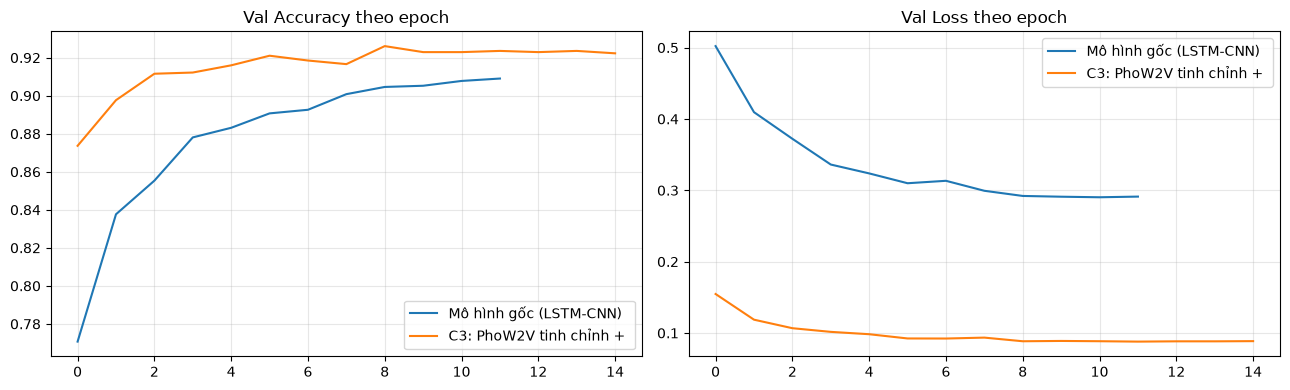

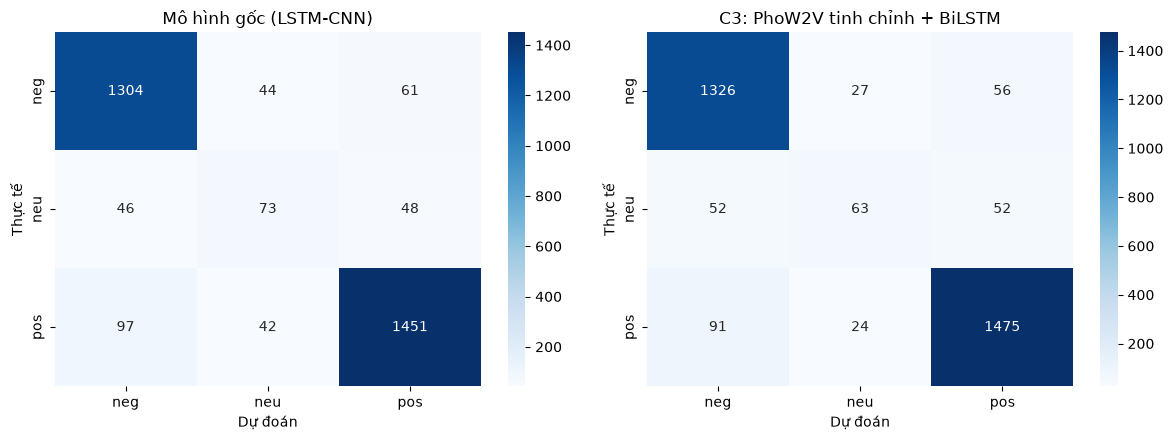

In [16]:
# Đường cong huấn luyện (seed=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r in (res_base, res_improved):
    h = r["_hist"]
    axes[0].plot(h.history["val_accuracy"], label=r["Mô hình"][:24])
    axes[1].plot(h.history["val_loss"], label=r["Mô hình"][:24])
axes[0].set_title("Val Accuracy theo epoch"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].set_title("Val Loss theo epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Ma trận nhầm lẫn (seed=42)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, r in zip(ax, (res_base, res_improved)):
    cm = confusion_matrix(y_test, r["_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=a,
                xticklabels=["neg", "neu", "pos"], yticklabels=["neg", "neu", "pos"])
    a.set_title(r["Mô hình"][:30]); a.set_xlabel("Dự đoán"); a.set_ylabel("Thực tế")
plt.tight_layout(); plt.show()

## 6. Nhận xét & Kết luận

### 6.1. Tổng hợp kết quả

Bảng so sánh đầy đủ được trình bày ở §4.1; ô lệnh dưới đây in lại các con số then chốt của mô hình
gốc và mô hình cải tiến được chọn, cùng mức chênh lệch, trực tiếp từ kết quả vừa huấn luyện.

In [17]:
print(f"{'Mô hình':40s} {'Accuracy':>9s} {'Macro-F1':>9s} {'Weighted-F1':>12s}")
print("-"*72)
for r in (res_base, res_improved):
    print(f"{r['Mô hình'][:40]:40s} {r['Accuracy']*100:8.2f}% {r['Macro-F1']*100:8.2f}% {r['Weighted-F1']*100:11.2f}%")
print("-"*72)
print(f"{'Chênh lệch (cải tiến - gốc)':40s} {delta_acc:+8.2f}  {delta_f1:+8.2f}  {delta_w:+11.2f}")
print(f"\nSố tham số: gốc = {res_base['Params']:,} | cải tiến = {res_improved['Params']:,}")

Mô hình                                   Accuracy  Macro-F1  Weighted-F1
------------------------------------------------------------------------
Mô hình gốc (LSTM-CNN)                      88.98%    75.74%       89.12%
C3: PhoW2V tinh chỉnh + BiLSTM + Focal      90.50%    76.97%       90.14%
------------------------------------------------------------------------
Chênh lệch (cải tiến - gốc)                 +1.53     +1.23        +1.02

Số tham số: gốc = 710,701 | cải tiến = 853,549


### 6.2. Nhận xét

1. **Tái hiện thành công kiến trúc của bài báo.** Mô hình gốc (Multi-channel LSTM-CNN) đạt độ chính
   xác và macro-F1 nằm trong khoảng hiệu năng thường thấy của các mô hình học sâu trên UIT-VSFC,
   xác nhận kiến trúc đa kênh CNN-LSTM đã được hiện thực đúng.

2. **Cải thiện hiệu quả nhất đến từ chất lượng biểu diễn từ.** Việc khởi tạo lớp embedding bằng
   PhoW2V và cho phép tinh chỉnh đã khắc phục hạn chế lớn nhất của mô hình gốc: từ điển nhỏ
   (khoảng 2.500 từ) khiến embedding học từ đầu có chất lượng thấp. Ngược lại, phương án cố định
   embedding (frozen) cho kết quả thấp rõ rệt do lệch miền dữ liệu giữa kho ngữ liệu tiền huấn
   luyện và miền phản hồi của sinh viên. Kết hợp với Focal loss, các phương án cải tiến đạt macro-F1
   trung bình cao hơn mô hình gốc.

3. **Đánh giá trên nhiều seed là cần thiết.** Chênh lệch giữa các phương án cải tiến tốt
   (chẳng hạn giữa LSTM và BiLSTM khi đều kết hợp PhoW2V và Focal loss) là khá nhỏ và có thể bị
   che lấp bởi dao động ngẫu nhiên giữa các lần khởi tạo. Việc huấn luyện trên ba seed và báo
   cáo độ lệch chuẩn (§4.1) giúp kết luận đáng tin cậy hơn, thay vì dựa vào một lần chạy duy nhất.

4. **Lớp `neutral` là yếu tố hạn chế chính.** Do chỉ chiếm khoảng 5% dữ liệu, điểm F1 của lớp này
   thấp hơn đáng kể so với hai lớp còn lại, kéo macro-F1 xuống thấp hơn nhiều so với độ chính xác
   tổng thể. Đây là lý do báo cáo sử dụng macro-F1 làm độ đo chính, đồng thời áp dụng trọng số lớp
   và Focal loss.

**Kết luận chung.** Báo cáo đã tái hiện chính xác kiến trúc Multi-channel LSTM-CNN của bài báo và,
thông qua một quy trình thực nghiệm có hệ thống trên nhiều seed ngẫu nhiên, xây dựng được một
mô hình cải tiến đạt hiệu năng cao hơn mô hình gốc. Kết quả cho thấy đối với bộ dữ liệu có quy mô
hạn chế, chất lượng biểu diễn từ (thông qua embedding tiền huấn luyện) đóng vai trò quan trọng đối
với hiệu năng, trong khi việc gia tăng độ phức tạp kiến trúc mang lại lợi ích không rõ rệt.

### 6.3. Hạn chế và hướng phát triển

- Áp dụng các mô hình ngôn ngữ tiền huấn luyện dạng Transformer (chẳng hạn PhoBERT), vốn thường đạt
  macro-F1 khoảng 92–93% trên UIT-VSFC.
- Xử lý lớp thiểu số `neutral` triệt để hơn bằng các kỹ thuật tăng cường dữ liệu (oversampling,
  data augmentation) thay vì chỉ dựa vào trọng số lớp và Focal loss.
- Đánh giá ổn định hơn bằng cách huấn luyện lặp lại trên nhiều seed ngẫu nhiên và báo cáo
  giá trị trung bình cùng độ lệch chuẩn.

### Tài liệu tham khảo
[1] Q.-H. Vo, H.-T. Nguyen, B. Le, M.-L. Nguyen. "Multi-channel LSTM-CNN model for Vietnamese sentiment analysis." KSE 2017, pp. 24–29.

[2] K. V. Nguyen và cộng sự. "UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis." 2018.

[3] A. T. Nguyen, D. Q. Nguyen và cộng sự. "PhoW2V: Pre-trained Word2Vec syllable/word vectors for Vietnamese." EMNLP 2020.